# 01. Trend Analysis: Understanding Performance Over Time
### Primary Analytical Purpose: *How does it change over time?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Identify Long-Term Trends**: Recognize upward growth, stagnation, or downward trajectories across a continuous timeline.
- **Detect Seasonality and Cycles**: Spot recurring patterns, peak demand periods, and cyclical slowdowns.
- **Select the Right Visualizations**: Implement static line charts using **Seaborn** and interactive time-series plots using **Plotly Express**.
- **Formulate Actionable Recommendations**: Translate time-based observations into proactive inventory, staffing, and marketing strategies.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *Apex Retail Co.* — an omni-channel consumer retail business.  
**Context:** Apex's executive leadership team is preparing for their annual strategy offsite. The Chief Commercial Officer (CCO) needs to understand how sales and transaction volumes have evolved over the past 24 months (two full calendar years: 2024 and 2025).

As a junior data analyst, your role is to examine the monthly performance records, visualize the trends, identify when peak sales occur, and advise the executive committee on future inventory and marketing planning.


In [1]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We generate a realistic 24-month dataset representing monthly retail sales and order volumes from January 2024 through December 2025.
The data includes:
- An underlying upward growth trend (~$2,000 monthly baseline increase)
- Mid-year summer bumps (July/August)
- Pronounced year-end holiday shopping surges (November and December)


In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate 24 consecutive month periods (Jan 2024 - Dec 2025)
dates = pd.date_range(start="2024-01-01", periods=24, freq="MS")

# Base upward trend
base_sales = np.linspace(48000, 96000, 24)

# Seasonal factors: holiday spikes in Nov (index 10, 22) and Dec (index 11, 23), slight summer bump
seasonality = np.array([
    -2000, -3000, 1000, 2000, 3000, 4000, 6000, 5000, 1000, 4000, 22000, 35000, # 2024
    -1000, -2000, 2000, 3500, 4500, 5500, 7500, 6500, 2500, 5500, 26000, 40000  # 2025
])

# Add mild random noise
noise = np.random.normal(0, 1500, 24)

# Calculate final monthly sales and orders
sales = np.round(base_sales + seasonality + noise, -2)
orders = np.round(sales / np.random.uniform(72, 85, 24)).astype(int)

# Create DataFrame
df = pd.DataFrame({
    "date": dates,
    "sales": sales,
    "orders": orders
})

# Display confirmation
print(f"Dataset successfully created: {df.shape[0]} months of data.")


Dataset successfully created: 24 months of data.


## 4. Dataset Preview

Always inspect the first few rows, summary statistics, and column data types before creating visualizations.


In [3]:
# Display the first 6 rows of the dataset
df.head(6)


,date,sales,orders
0,2024-01-01,46700.0,586
1,2024-02-01,46900.0,646
2,2024-03-01,54100.0,677
3,2024-04-01,58500.0,788
4,2024-05-01,59000.0,810
5,2024-06-01,62100.0,736


In [4]:
# Check column types and ensure there are no missing values
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    24 non-null     datetime64[us]
 1   sales   24 non-null     float64       
 2   orders  24 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 708.0 bytes


In [5]:
# View summary statistics for numerical metrics
df.describe().round(2)


,date,sales,orders
count,24,24.00,24.00
mean,2024-12-15 22:00:00,79216.67,1010.79
min,2024-01-01 00:00:00,46700.00,586.00
25%,2024-06-23 12:00:00,64275.00,813.75
50%,2024-12-16 12:00:00,74500.00,981.00
75%,2025-06-08 12:00:00,91775.00,1174.25
max,2025-12-01 00:00:00,133900.00,1631.00
std,NaN,21799.65,262.56


## 5. Analytical Questions

As an analyst investigating this time-series data, you need to answer:
1. **Direction of Change:** Are retail sales generally increasing, decreasing, or flat over the 24-month horizon?
2. **Extreme Periods:** Which specific months represent our highest performance peaks and lowest troughs?
3. **Seasonality:** Is there a predictable, recurring monthly rhythm across both years?


## 6. Seaborn Visualization (Static Publication Chart)

A **line chart** is the industry standard for time-series data because the connected markers clearly illustrate direction, velocity, and turning points.

Below, we create a publication-ready line chart with clear title, axis labels, markers, and formatted date ticks.


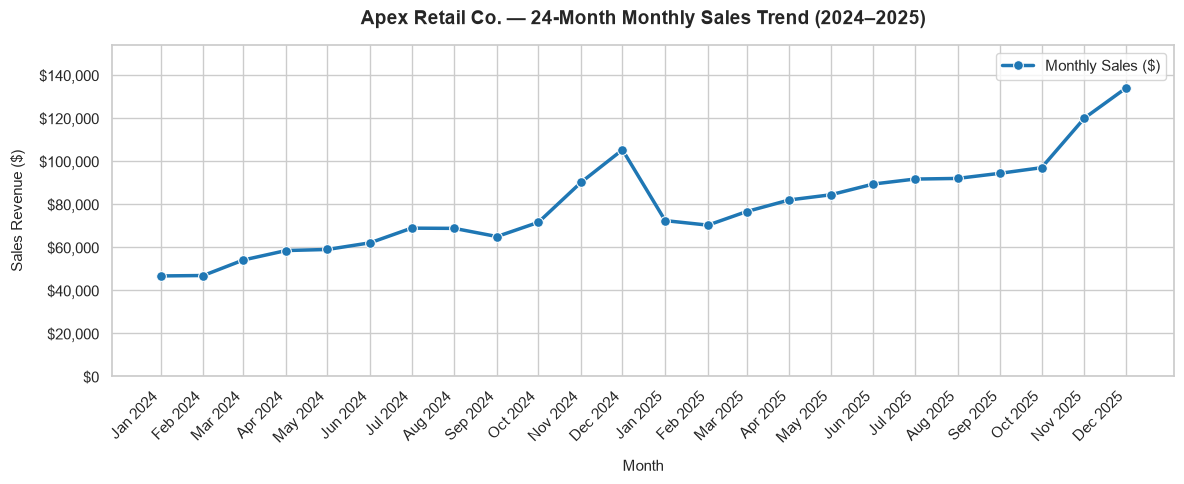

In [6]:
# Create figure and axis
plt.figure(figsize=(12, 5))

# Plot monthly sales trend
sns.lineplot(
    data=df,
    x="date",
    y="sales",
    marker="o",
    markersize=7,
    color="#1f77b4",
    linewidth=2.5,
    label="Monthly Sales ($)"
)

# Customize title and labels
plt.title("Apex Retail Co. — 24-Month Monthly Sales Trend (2024–2025)", fontsize=14, pad=15, fontweight="bold")
plt.xlabel("Month", fontsize=11, labelpad=10)
plt.ylabel("Sales Revenue ($)", fontsize=11, labelpad=10)

# Format y-axis with comma separators for clean reading
plt.gca().yaxis.set_major_formatter('${x:,.0f}')

# Rotate x-axis labels for readability
plt.xticks(df["date"], df["date"].dt.strftime("%b %Y"), rotation=45, ha="right")
plt.ylim(0, df["sales"].max() * 1.15) # Start y-axis at 0 for truthful proportion
plt.tight_layout()

# Display chart
plt.show()


## 7. Plotly Express Visualization (Interactive Web Chart)

While static charts are great for printed reports, **Plotly Express** provides interactive charts ideal for web dashboards and presentations.
- **Hover** over any point to see the exact date, sales revenue, and total orders.
- **Click and drag** to zoom into any quarter.
- **Double click** anywhere to reset the view.


In [7]:
# Create interactive line chart
fig = px.line(
    df,
    x="date",
    y="sales",
    markers=True,
    title="<b>Interactive Sales Trend (2024–2025)</b>",
    labels={"date": "Month", "sales": "Sales Revenue ($)", "orders": "Total Orders"},
    hover_data={"orders": ":,", "sales": ":$,.0f", "date": "|%B %Y"}
)

# Customize layout aesthetics
fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Sales Revenue ($)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.0f",
    hovermode="x unified",
    template="plotly_white"
)

# Display interactive chart
fig.show()


## 8. Interpretation

Let us break down what the visualization reveals:

1. **Overall Trajectory (Trend):**
   - The sales line shows a distinct upward slope from left to right.
   - In January 2024, sales began near **$47,000**. By December 2025, sales reached a peak of **~$136,000**.
   - Year 2 (2025) consistently outperformed the equivalent months of Year 1 (2024), demonstrating genuine annual business growth rather than just temporary spikes.

2. **Seasonal Peaks (Seasonality):**
   - In both 2024 and 2025, sales climbed gradually through spring and summer, experienced a minor peak in July, and then surged drastically in **November and December**.
   - December is unquestionably the primary revenue driver of each year, generating more than double the revenue of January or February.

3. **Troughs and Slumps:**
   - The lowest-performing months are consistently **January and February** of each year.
   - Following the massive December holiday spike, sales experience a sharp contraction in January as consumer post-holiday spending contracts.


## 9. Key Insights & Recommended Business Actions

### What Happened?
- Apex Retail experienced steady ~25% year-over-year revenue expansion across the 24-month evaluation period.
- Q4 (specifically November and December) generates approximately **35% of total annual sales**.

### Actionable Business Recommendations:
1. **Supply Chain & Inventory Management:** 
   - Increase purchase orders and warehouse stock by early September to ensure fulfillment centers are fully stocked ahead of the November holiday surge.
2. **Staffing and Logistics:**
   - Onboard temporary customer service and warehouse fulfillment staff starting in mid-October, phasing them out by mid-January.
3. **Post-Holiday Promotion:**
   - Launch clearance campaigns or loyalty reward promotions in January to soften the recurring post-holiday revenue dip.

---

### Common Analytical Mistake to Avoid:
> **Mistake: Truncating the Time Axis or Connecting Unrelated Categories**  
> Line charts imply continuous sequence. Never use a line chart to connect unordered categories (such as product departments or store locations), because lines falsely suggest a chronological transition between them. Furthermore, be cautious when truncating the vertical axis: starting a sales line chart at $40,000 instead of $0 can visually exaggerate minor fluctuations into alarming spikes or collapses.


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Review the visualizations above and answer in your own words:
1. Which single month achieved the highest total sales in the 24-month period?
2. Which single month recorded the lowest total sales?
3. Describe the change that occurs between December 2024 and January 2025.


### Exercise 2: Modify Chart Settings
In the code cell below, create a Seaborn line plot displaying **`orders`** (order volume) over time instead of sales:
- Change the line color to `'teal'` (`#008080`).
- Use square markers (`marker='s'`).
- Give the chart an informative title: *"Apex Retail Co. — Monthly Order Volume Trend (2024–2025)"*.


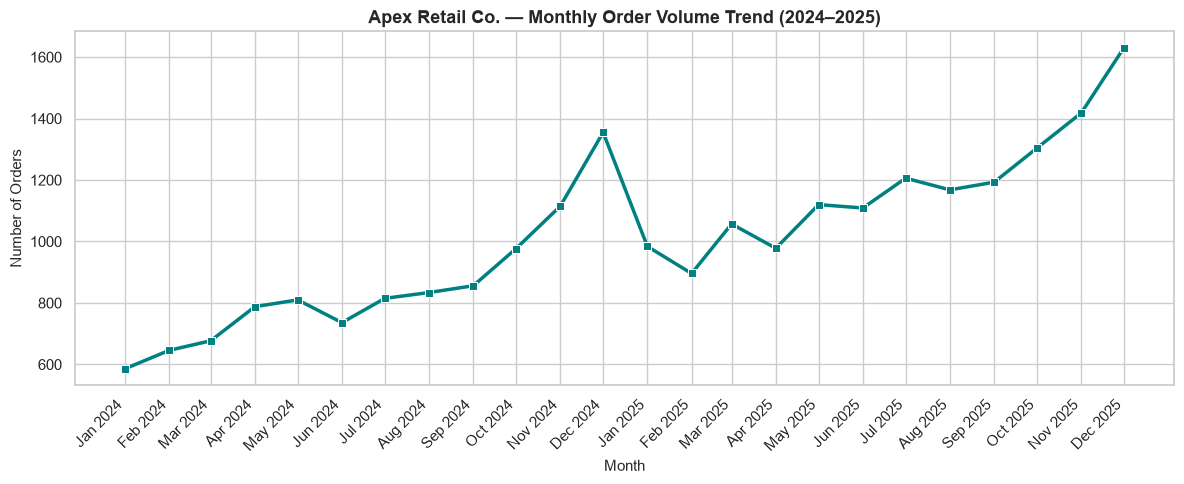

In [8]:
# Exercise 2: Student Code
plt.figure(figsize=(12, 5))

# Create your line plot for orders below:
sns.lineplot(
    data=df,
    x="date",
    y="orders",
    marker="s",
    color="#008080",
    linewidth=2.5
)

plt.title("Apex Retail Co. — Monthly Order Volume Trend (2024–2025)", fontsize=13, fontweight="bold")
plt.xlabel("Month", fontsize=11)
plt.ylabel("Number of Orders", fontsize=11)
plt.xticks(df["date"], df["date"].dt.strftime("%b %Y"), rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Exercise 3: Answer a Business Question
Calculate the average monthly sales for **Year 1 (2024)** versus **Year 2 (2025)** to quantify the annual growth rate in dollars and percent.


In [9]:
# Exercise 3: Student Code
# Calculate Year 1 (2024) average sales
avg_2024 = df[df["date"].dt.year == 2024]["sales"].mean()

# Calculate Year 2 (2025) average sales
avg_2025 = df[df["date"].dt.year == 2025]["sales"].mean()

growth_pct = ((avg_2025 - avg_2024) / avg_2024) * 100

print(f"2024 Average Monthly Sales: ${avg_2024:,.2f}")
print(f"2025 Average Monthly Sales: ${avg_2025:,.2f}")
print(f"Year-over-Year Average Growth: +{growth_pct:.1f}%")


2024 Average Monthly Sales: $66,425.00
2025 Average Monthly Sales: $92,008.33
Year-over-Year Average Growth: +38.5%


## 11. Challenge Activity

**Metric Engineering & Dual-Axis Thinking:**  
In business analytics, tracking sales alone does not tell you whether growth was driven by more customers purchasing or by customers spending more per transaction.

1. In the cell below, calculate **Average Order Value (AOV)**:
   $$\text{AOV} = \frac{\text{sales}}{\text{orders}}$$
2. Create an interactive Plotly line chart showing AOV over time.
3. Write two brief analytical insights explaining whether customer spend per order changes during holiday peak months.


In [10]:
# Challenge Activity: Calculate AOV and plot trend
df["aov"] = df["sales"] / df["orders"]

fig_aov = px.line(
    df,
    x="date",
    y="aov",
    markers=True,
    title="<b>Monthly Average Order Value (AOV) Trend</b>",
    labels={"date": "Month", "aov": "Average Order Value ($)"}
)
fig_aov.update_layout(yaxis_tickprefix="$", template="plotly_white")
fig_aov.show()

# Print summary
print(f"Mean AOV across all 24 months: ${df['aov'].mean():.2f}")


Mean AOV across all 24 months: $78.25


## 12. Key Takeaways

- **When to Use:** Use a **line chart** whenever your independent variable is ordered and continuous (such as time: days, months, quarters, or years).
- **Slope Equals Velocity:** The steepness of the line indicates the rate of change. Steeper slopes mean faster growth or decline.
- **Deconstruct Time-Series:** Always analyze time series into three components: **Long-term trend** (underlying direction), **Seasonality** (repeating cycles), and **Anomalies / Noise** (unusual spikes or dips).
- **Tool Selection:**
  - Use **Seaborn** for polished, static visualizations in formal documents and executive slide presentations.
  - Use **Plotly Express** for data exploration, dashboards, and client-facing web applications where users benefit from tooltips and zooming.
